# 🎙️ Voice-Based Faint Detection — TESS Dataset

**Dataset:** Toronto Emotional Speech Set (TESS)  
**Kaggle:** https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess

### Label Mapping Strategy
| TESS Emotion | Our Label |
|---|---|
| `fear` | Faint Risk |
| `angry` | Faint Risk |
| `disgust` | Faint Risk |
| `ps` (pleasant surprise → panic-like) | Faint Risk |
| `neutral` | Normal |
| `happy` | Normal |
| `sad` | Normal |

### Pipeline
```
TESS WAV Files
     ↓
Emotion → Binary Label (Normal / Faint Risk)
     ↓
Audio Augmentation
     ↓
YAMNet Embeddings (1024-dim)
     ↓
MLP Classifier
     ↓
Normal / Faint Risk + Emergency Alert
```

---
## STEP 1 — Install Libraries

In [29]:
!pip install -q tensorflow tensorflow_hub librosa scikit-learn matplotlib seaborn tqdm

---
## STEP 2 — Imports

In [30]:
import os, warnings, pickle
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input, LeakyReLU
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print('✅ All libraries imported')

TensorFlow : 2.19.0
✅ All libraries imported


---
## STEP 3 — Configuration

In [31]:
import glob

# ── Auto-detect le bon path ────────────────────────────────────────
_wavs = glob.glob('/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/**/*.wav', recursive=True)
DATASET_ROOT = Path(_wavs[0]).parent.parent

SAMPLE_RATE  = 16000
DURATION     = 3
SAMPLES      = SAMPLE_RATE * DURATION
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 1e-3
MODEL_PATH   = 'faint_detection_tess.h5'

FAINT_EMOTIONS  = {'fear', 'angry', 'disgust', 'ps'}
NORMAL_EMOTIONS = {'neutral', 'happy', 'sad'}
CLASS_NAMES     = ['Normal', 'Faint Risk']

print('✅ Config set')
print(f'   Dataset root : {DATASET_ROOT}')
print(f'   Existe       : {DATASET_ROOT.exists()}')
print(f'   Faint labels : {FAINT_EMOTIONS}')
print(f'   Normal labels: {NORMAL_EMOTIONS}')

✅ Config set
   Dataset root : /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data
   Existe       : True
   Faint labels : {'ps', 'disgust', 'angry', 'fear'}
   Normal labels: {'happy', 'neutral', 'sad'}


---
## STEP 4 — Explore TESS Dataset Structure

In [32]:
import os
base = Path('/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess')
for root, dirs, files in os.walk(base):
    level = root.replace(str(base), '').count(os.sep)
    if level > 3:
        break
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        print(f"{indent}  → {len(files)} fichiers, ex: {files[0]}")

toronto-emotional-speech-set-tess/
  TESS Toronto emotional speech set data/
    YAF_fear/
      → 200 fichiers, ex: YAF_home_fear.wav
    OAF_angry/
      → 200 fichiers, ex: OAF_raid_angry.wav
    OAF_Fear/
      → 200 fichiers, ex: OAF_gap_fear.wav
    OAF_disgust/
      → 200 fichiers, ex: OAF_good_disgust.wav
    OAF_neutral/
      → 200 fichiers, ex: OAF_soup_neutral.wav
    YAF_angry/
      → 200 fichiers, ex: YAF_shack_angry.wav
    OAF_Sad/
      → 200 fichiers, ex: OAF_germ_sad.wav
    YAF_disgust/
      → 200 fichiers, ex: YAF_bar_disgust.wav
    YAF_neutral/
      → 200 fichiers, ex: YAF_thought_neutral.wav
    OAF_Pleasant_surprise/
      → 200 fichiers, ex: OAF_met_ps.wav
    YAF_happy/
      → 200 fichiers, ex: YAF_jail_happy.wav
    OAF_happy/
      → 200 fichiers, ex: OAF_fall_happy.wav
    YAF_sad/
      → 200 fichiers, ex: YAF_chair_sad.wav
    YAF_pleasant_surprised/
      → 200 fichiers, ex: YAF_burn_ps.wav
  tess toronto emotional speech set data/
    TESS Toronto

In [33]:
records = []

for folder in sorted(DATASET_ROOT.iterdir()):
    if not folder.is_dir():
        continue
    folder_lower = folder.name.lower()

    emotion = None
    for e in FAINT_EMOTIONS | NORMAL_EMOTIONS:
        if e in folder_lower:
            emotion = e
            break
    if emotion is None:
        continue

    label = 1 if emotion in FAINT_EMOTIONS else 0

    for wav in folder.glob('*.wav'):
        records.append({'path': str(wav), 'emotion': emotion, 'label': label})

df = pd.DataFrame(records)

print(f'Total WAV files found : {len(df)}')

if len(df) == 0:
    raise RuntimeError(
        f"❌ Aucun fichier WAV trouvé !\n"
        f"Path utilisé : {DATASET_ROOT}\n"
        f"Path existe  : {DATASET_ROOT.exists()}"
    )

print(f'\nDistribution by emotion:')
print(df.groupby(['emotion', 'label']).size().reset_index(name='count').to_string(index=False))
print(f'\nClass balance:')
print(f'  Normal     (0) : {(df.label==0).sum()}')
print(f'  Faint Risk (1) : {(df.label==1).sum()}')

Total WAV files found : 2400

Distribution by emotion:
emotion  label  count
  angry      1    400
disgust      1    400
   fear      1    400
  happy      0    400
neutral      0    400
    sad      0    400

Class balance:
  Normal     (0) : 1200
  Faint Risk (1) : 1200


---
## STEP 5 — Visualize Samples

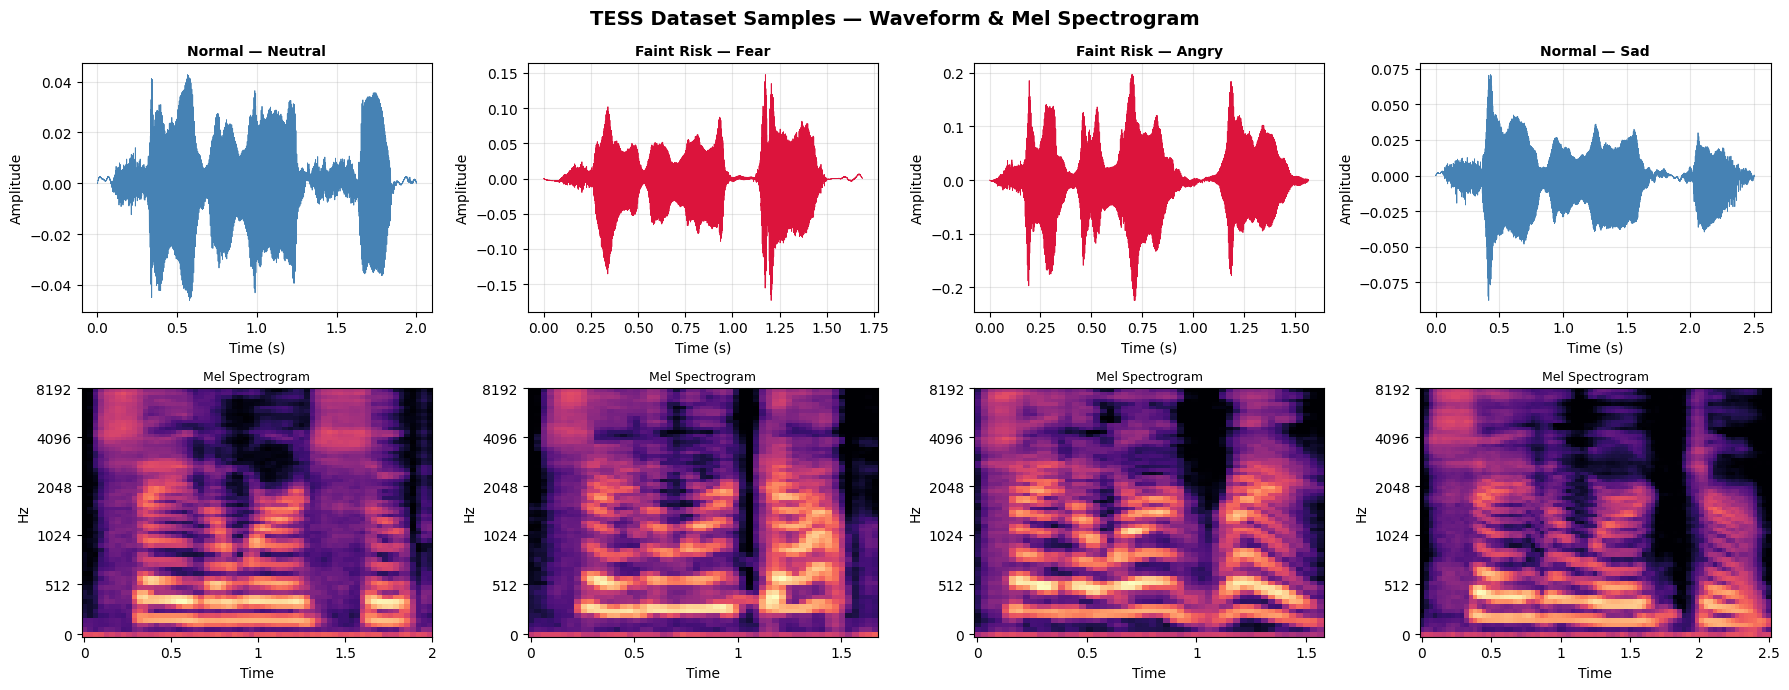

✅ Saved: dataset_samples.png


In [34]:
sample_emotions = ['neutral', 'fear', 'angry', 'sad']
titles = ['Normal — Neutral', 'Faint Risk — Fear', 'Faint Risk — Angry', 'Normal — Sad']
colors = ['steelblue', 'crimson', 'crimson', 'steelblue']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('TESS Dataset Samples — Waveform & Mel Spectrogram', fontsize=14, fontweight='bold')

for col, (emo, title, color) in enumerate(zip(sample_emotions, titles, colors)):
    row = df[df.emotion == emo].iloc[0]
    audio, _ = librosa.load(row['path'], sr=SAMPLE_RATE, duration=DURATION)
    t = np.linspace(0, len(audio)/SAMPLE_RATE, len(audio))

    axes[0, col].plot(t, audio, lw=0.6, color=color)
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel('Time (s)')
    axes[0, col].set_ylabel('Amplitude')
    axes[0, col].grid(alpha=0.3)

    mel = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SAMPLE_RATE, ax=axes[1, col],
                             x_axis='time', y_axis='mel', cmap='magma')
    axes[1, col].set_title(f'Mel Spectrogram', fontsize=9)

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: dataset_samples.png')

---
## STEP 6 — Load YAMNet

In [35]:
print('Loading YAMNet from TensorFlow Hub (requires internet)...')
yamnet = hub.load('https://tfhub.dev/google/yamnet/1')

# Quick shape test
_audio, _ = librosa.load(df.iloc[0]['path'], sr=SAMPLE_RATE, duration=DURATION)
_audio = np.pad(_audio, (0, max(0, SAMPLES - len(_audio))))[:SAMPLES]
_, _emb, _ = yamnet(tf.constant(_audio, dtype=tf.float32))

print(f'✅ YAMNet loaded')
print(f'   Frames shape  : {_emb.shape}')
print(f'   Embedding dim : {_emb.shape[-1]}  (mean-pooled → 1024-d vector per clip)')

Loading YAMNet from TensorFlow Hub (requires internet)...


I0000 00:00:1777807086.159675      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777807086.165542      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777807091.278896     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


✅ YAMNet loaded
   Frames shape  : (6, 1024)
   Embedding dim : 1024  (mean-pooled → 1024-d vector per clip)


---
## STEP 7 — Audio Augmentation Functions

In [36]:
def add_noise(audio, snr_db=None):
    snr_db = snr_db or np.random.uniform(20, 40)
    power  = np.mean(audio**2)
    noise  = np.random.normal(0, np.sqrt(power / 10**(snr_db/10)), len(audio))
    return (audio + noise).astype(np.float32)

def time_shift(audio):
    shift = int(np.random.uniform(-0.2, 0.2) * SAMPLE_RATE)
    return np.roll(audio, shift).astype(np.float32)

def random_gain(audio):
    return np.clip(audio * np.random.uniform(0.7, 1.3), -1, 1).astype(np.float32)

def pitch_stretch(audio):
    rate = np.random.uniform(0.9, 1.1)
    return librosa.effects.time_stretch(audio, rate=rate).astype(np.float32)

def augment(audio):
    fns = [add_noise, time_shift, random_gain]
    for fn in np.random.choice(fns, size=np.random.randint(1, 3), replace=False):
        audio = fn(audio)
    mx = np.max(np.abs(audio)) + 1e-8
    return (audio / mx).astype(np.float32)

print('✅ Augmentation functions ready')

✅ Augmentation functions ready


---
## STEP 8 — Feature Extraction (YAMNet Embeddings)

In [37]:
def extract_embedding(path, do_augment=False):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION)
    if len(audio) < SAMPLES:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))
    audio = audio[:SAMPLES]
    if do_augment:
        audio = augment(audio)
    _, embs, _ = yamnet(tf.constant(audio, dtype=tf.float32))
    return np.mean(embs.numpy(), axis=0)   # (1024,)


# ── Extract all embeddings + 2 augmented copies per file ─────────
X, y_labels = [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting embeddings'):
    # Original
    X.append(extract_embedding(row['path'], do_augment=False))
    y_labels.append(row['label'])
    # Aug ×2
    for _ in range(2):
        X.append(extract_embedding(row['path'], do_augment=True))
        y_labels.append(row['label'])

X = np.array(X, dtype=np.float32)
y = np.array(y_labels, dtype=np.int32)

print(f'\n✅ Embeddings extracted')
print(f'   X shape          : {X.shape}')
print(f'   Normal (0)       : {(y==0).sum()}')
print(f'   Faint Risk (1)   : {(y==1).sum()}')

Extracting embeddings: 100%|██████████| 2400/2400 [01:27<00:00, 27.45it/s]


✅ Embeddings extracted
   X shape          : (7200, 1024)
   Normal (0)       : 3600
   Faint Risk (1)   : 3600


---
## STEP 9 — Train / Val / Test Split + Normalization

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=SEED)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('✅ Split & normalized')
print(f'   Train : {X_train.shape[0]}')
print(f'   Val   : {X_val.shape[0]}')
print(f'   Test  : {X_test.shape[0]}')

✅ Split & normalized
   Train : 5202
   Val   : 918
   Test  : 1080


---
## STEP 10 — Build Model

In [39]:
def build_model(dim=1024):
    inp = Input(shape=(dim,))

    x = Dense(512, kernel_regularizer=l2(1e-4))(inp)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.35)(x)

    x = Dense(256, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.30)(x)

    x = Dense(128, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.25)(x)

    x = Dense(64, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.15)(x)

    out = Dense(1, activation='sigmoid')(x)

    m = Model(inp, out, name='FaintDetector_TESS')
    m.compile(
        optimizer=Adam(LR, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return m

model = build_model()
model.summary()
print(f'\n✅ Model built — {model.count_params():,} parameters')

Model: "FaintDetector_TESS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 701,185 (2.67 MB)

 Trainable params: 699,265 (2.67 MB)

 Non-trainable params: 1,920 (7.50 KB)


✅ Model built — 701,185 parameters


---
## STEP 11 — Train

In [40]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=5,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_auc', save_best_only=True,
                    mode='max', verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training complete')

Epoch 1/100


I0000 00:00:1777807185.031166     157 service.cc:152] XLA service 0x78e804001f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777807185.031220     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777807185.031227     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 45/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6083 - auc: 0.6837 - loss: 0.8048 - precision: 0.6784 - recall: 0.4697

I0000 00:00:1777807190.331256     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7041 - auc: 0.7908 - loss: 0.6788 - precision: 0.7274 - recall: 0.6549

...

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9810 - auc: 0.9979 - loss: 0.1415 - precision: 0.9788 - recall: 0.9836 - val_accuracy: 0.9760 - val_auc: 0.9983 - val_loss: 0.1383 - val_precision: 0.9802 - val_recall: 0.9717 - learning_rate: 1.6000e-04
Epoch 31/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9805 - auc: 0.9977 - loss: 0.1410 - precision: 0.9809 - recall: 0.9805 - val_accuracy: 0.9728 - val_auc: 0.9982 - val_loss: 0.1393 - val_precision: 0.9759 - val_recall: 0.9695 - learning_rate: 1.6000e-04
Epoch 32/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9776 - auc: 0.9973 - loss: 0.1435 - precision: 0.9769 - recall: 0.9789 - val_accuracy: 0.9695 - val_auc: 0.9980 - val_loss: 0.1406 - val_precision: 0.9736 - val_recall: 0.9651 - learning_rate: 1.6000e-04
Epoch 33/100
159/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9762 - auc: 0.9976 - loss: 0.1420 - precision: 0.9741 - recall: 0.9789

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9763 - auc: 0.9976 - loss: 0.1418 - precision: 0.9743 - recall: 0.9790 - val_accuracy: 0.9760 - val_auc: 0.9984 - val_loss: 0.1345 - val_precision: 0.9823 - val_recall: 0.9695 - learning_rate: 1.6000e-04
Epoch 34/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9788 - auc: 0.9975 - loss: 0.1412 - precision: 0.9787 - recall: 0.9794 - val_accuracy: 0.9706 - val_auc: 0.9982 - val_loss: 0.1361 - val_precision: 0.9696 - val_recall: 0.9717 - learning_rate: 1.6000e-04
Epoch 35/100
159/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9794 - auc: 0.9977 - loss: 0.1363 - precision: 0.9788 - recall: 0.9804

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9794 - auc: 0.9977 - loss: 0.1362 - precision: 0.9788 - recall: 0.9804 - val_accuracy: 0.9771 - val_auc: 0.9985 - val_loss: 0.1309 - val_precision: 0.9824 - val_recall: 0.9717 - learning_rate: 1.6000e-04
Epoch 36/100
160/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9812 - auc: 0.9981 - loss: 0.1313 - precision: 0.9803 - recall: 0.9827

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9813 - auc: 0.9981 - loss: 0.1311 - precision: 0.9804 - recall: 0.9828 - val_accuracy: 0.9760 - val_auc: 0.9985 - val_loss: 0.1276 - val_precision: 0.9719 - val_recall: 0.9804 - learning_rate: 1.6000e-04
Epoch 37/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9813 - auc: 0.9985 - loss: 0.1255 - precision: 0.9795 - recall: 0.9836 - val_accuracy: 0.9771 - val_auc: 0.9984 - val_loss: 0.1292 - val_precision: 0.9761 - val_recall: 0.9782 - learning_rate: 1.6000e-04
Epoch 38/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9790 - auc: 0.9980 - loss: 0.1308 - precision: 0.9788 - recall: 0.9800 - val_accuracy: 0.9662 - val_auc: 0.9974 - val_loss: 0.1489 - val_precision: 0.9652 - val_recall: 0.9673 - learning_rate: 1.6000e-04
Epoch 39/100
162/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9801 - auc: 0.9981 - loss: 0.1255 - precision: 0.9792 - recall: 0.9816

163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9801 - auc: 0.9981 - loss: 0.1254 - precision: 0.9792 - recall: 0.9817 - val_accuracy: 0.9793 - val_auc: 0.9987 - val_loss: 0.1255 - val_precision: 0.9846 - val_recall: 0.9739 - learning_rate: 1.6000e-04
Epoch 40/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9864 - auc: 0.9985 - loss: 0.1200 - precision: 0.9866 - recall: 0.9865 - val_accuracy: 0.9717 - val_auc: 0.9984 - val_loss: 0.1301 - val_precision: 0.9696 - val_recall: 0.9739 - learning_rate: 1.6000e-04
Epoch 41/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9825 - auc: 0.9986 - loss: 0.1199 - precision: 0.9815 - recall: 0.9839 - val_accuracy: 0.9717 - val_auc: 0.9982 - val_loss: 0.1319 - val_precision: 0.9717 - val_recall: 0.9717 - learning_rate: 1.6000e-04
Epoch 42/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9840 - auc: 0.9990 - loss: 0.1130 - precision: 0.9845 - recall: 0.9837 - val_accuracy: 0.9728 - val_auc: 0.9983 - val_loss: 0.131

---
## STEP 12 — Training Curves

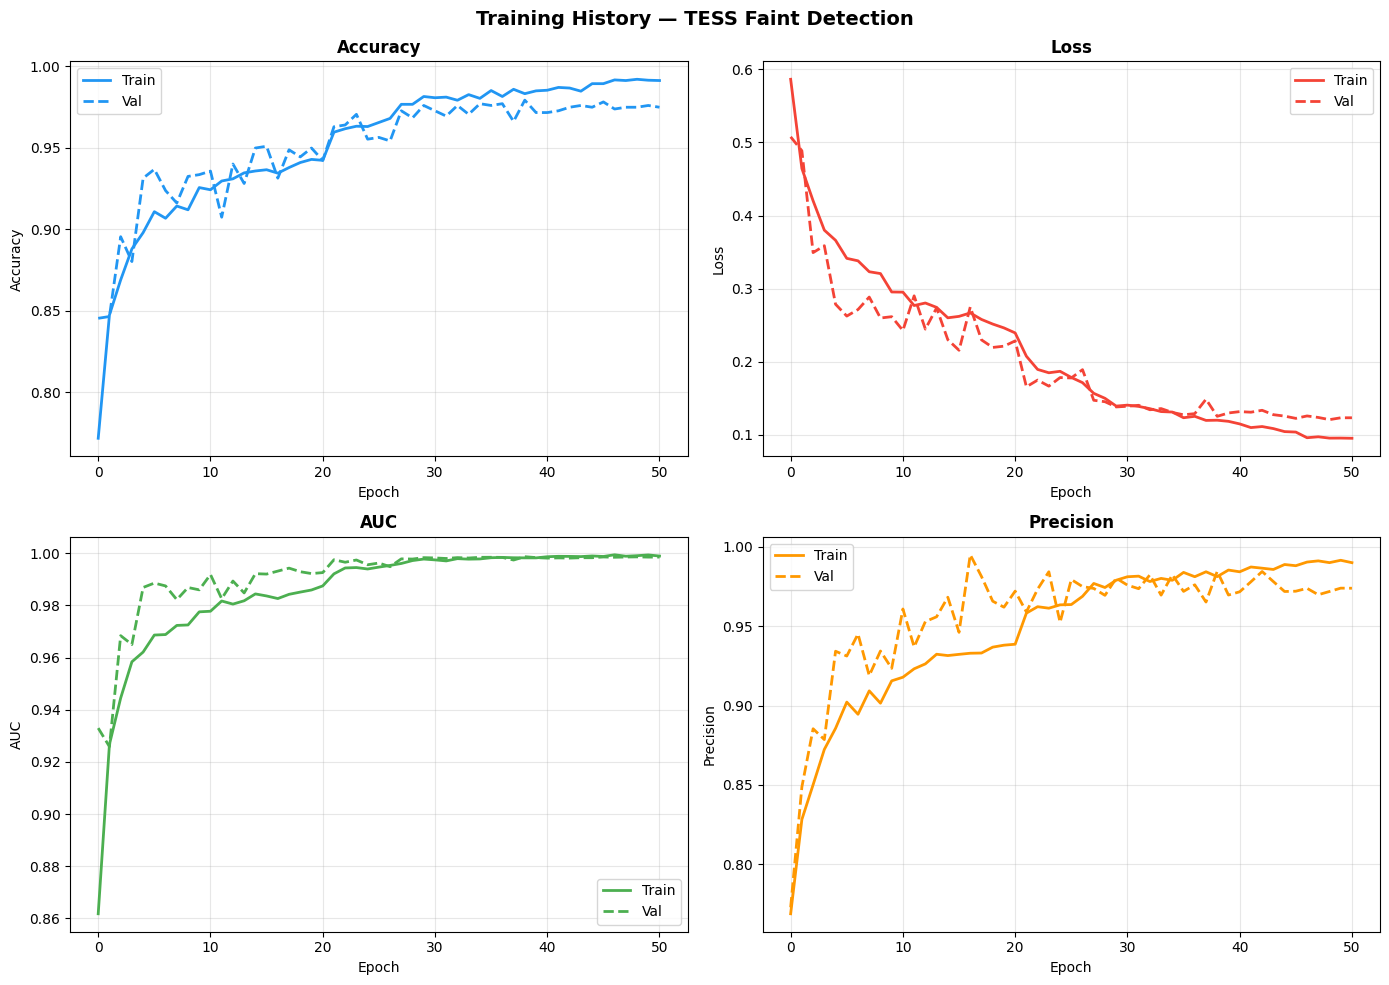

✅ Saved: training_curves.png


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — TESS Faint Detection', fontsize=14, fontweight='bold')

for ax, (m, title, color) in zip(axes.flat, [
    ('accuracy',  'Accuracy',  '#2196F3'),
    ('loss',      'Loss',      '#F44336'),
    ('auc',       'AUC',       '#4CAF50'),
    ('precision', 'Precision', '#FF9800'),
]):
    ax.plot(history.history[m], color=color, lw=2, label='Train')
    ax.plot(history.history[f'val_{m}'], color=color, lw=2, ls='--', label='Val')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: training_curves.png')

---
## STEP 13 — Evaluation

In [42]:
model = tf.keras.models.load_model(MODEL_PATH)

probs = model.predict(X_test, verbose=0).flatten()
preds = (probs >= 0.5).astype(int)

acc  = accuracy_score (y_test, preds)
prec = precision_score(y_test, preds)
rec  = recall_score   (y_test, preds)
f1   = f1_score       (y_test, preds)
auc  = roc_auc_score  (y_test, probs)

print('═'*50)
print('     FINAL EVALUATION — TESS FAINT DETECTION')
print('═'*50)
print(f'  Accuracy  : {acc *100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec *100:.2f}%')
print(f'  F1 Score  : {f1  *100:.2f}%')
print(f'  ROC-AUC   : {auc *100:.2f}%')
print('═'*50)
print('\n' + classification_report(y_test, preds, target_names=CLASS_NAMES))

if acc >= 0.95:
    print('🎯 TARGET ≥ 95% ACCURACY — ACHIEVED ✅')

══════════════════════════════════════════════════
     FINAL EVALUATION — TESS FAINT DETECTION
══════════════════════════════════════════════════
  Accuracy  : 97.87%
  Precision : 97.43%
  Recall    : 98.33%
  F1 Score  : 97.88%
  ROC-AUC   : 99.81%
══════════════════════════════════════════════════

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98       540
  Faint Risk       0.97      0.98      0.98       540

    accuracy                           0.98      1080
   macro avg       0.98      0.98      0.98      1080
weighted avg       0.98      0.98      0.98      1080

🎯 TARGET ≥ 95% ACCURACY — ACHIEVED ✅


---
## STEP 14 — Confusion Matrix

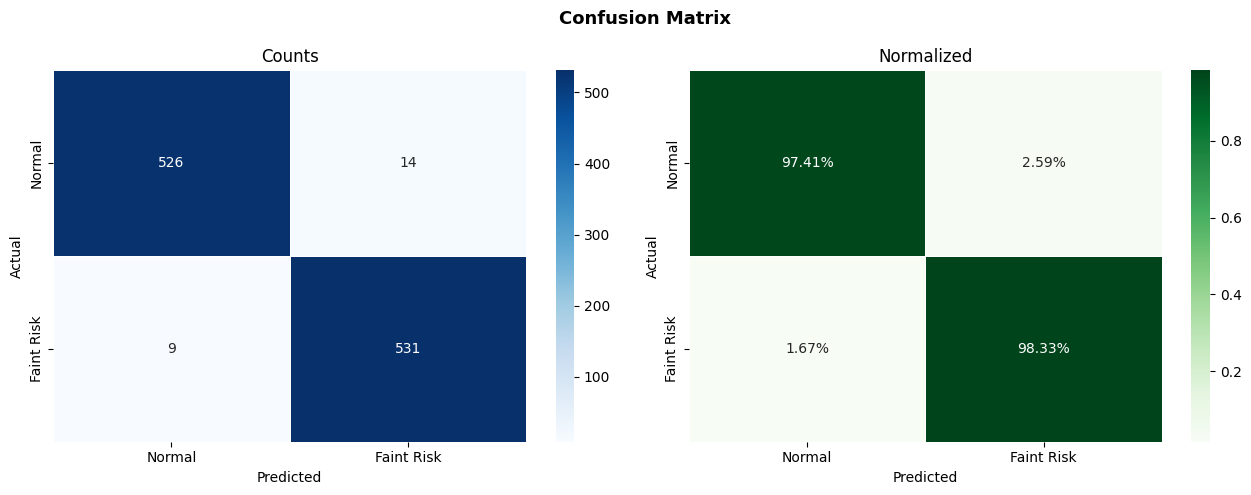

✅ Saved: confusion_matrix.png


In [43]:
cm = confusion_matrix(y_test, preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_n = cm.astype(float) / cm.sum(axis=1)[:, None]
sns.heatmap(cm_n, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix.png')

---
## STEP 15 — ROC Curve

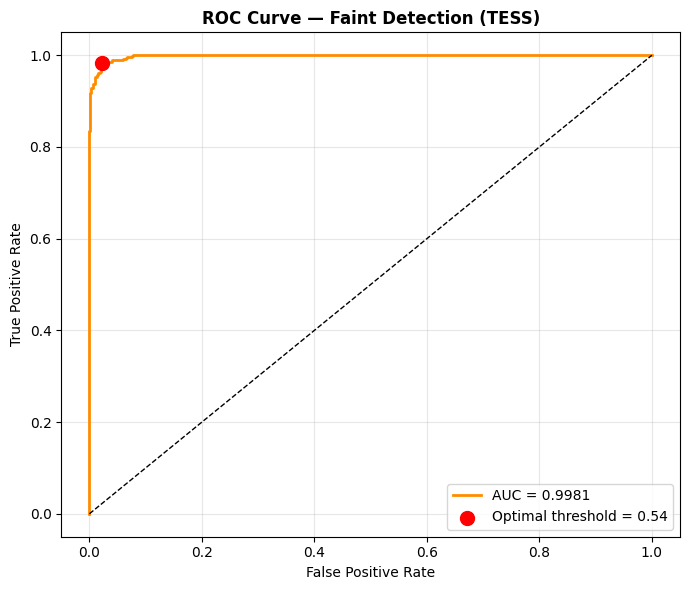

✅ Optimal threshold: 0.542


In [44]:
fpr, tpr, thresholds = roc_curve(y_test, probs)
opt_idx = np.argmax(tpr - fpr)
opt_thr = thresholds[opt_idx]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
            label=f'Optimal threshold = {opt_thr:.2f}')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Faint Detection (TESS)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Optimal threshold: {opt_thr:.3f}')

---
## STEP 16 — Metrics Dashboard

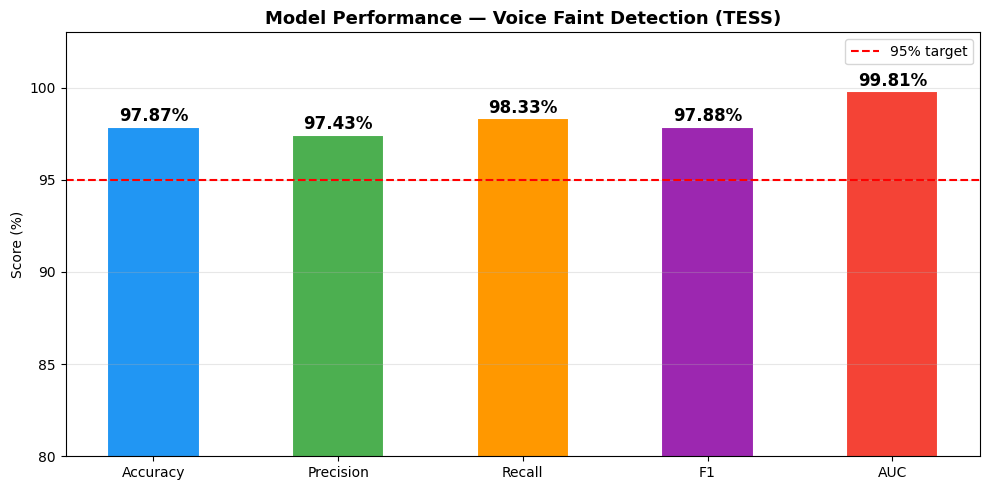

✅ Saved: metrics_dashboard.png


In [45]:
metrics_dict = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_dict.keys(), [v*100 for v in metrics_dict.values()],
              color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, metrics_dict.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax.axhline(95, color='red', ls='--', lw=1.5, label='95% target')
ax.set_ylim(80, 103); ax.set_ylabel('Score (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Model Performance — Voice Faint Detection (TESS)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: metrics_dashboard.png')

---
## STEP 17 — Probability Distribution

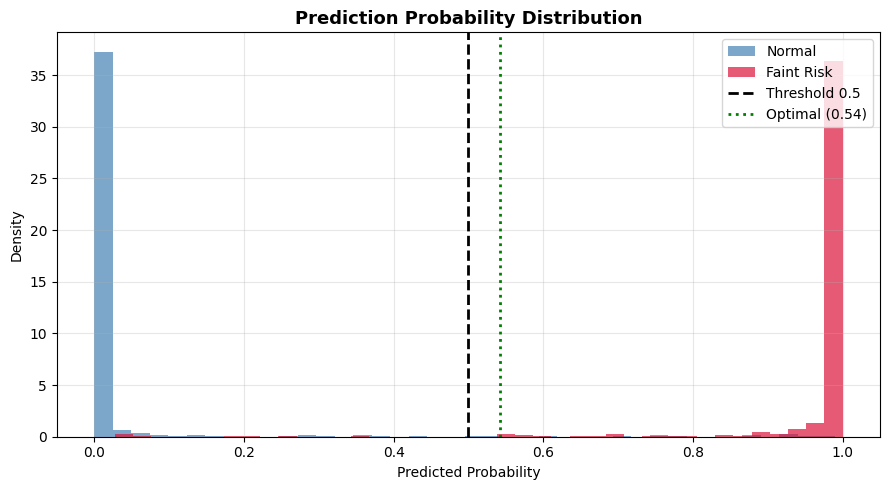

✅ Saved: prob_distribution.png


In [46]:
plt.figure(figsize=(9, 5))
plt.hist(probs[y_test==0], bins=40, alpha=0.7, color='steelblue', label='Normal', density=True)
plt.hist(probs[y_test==1], bins=40, alpha=0.7, color='crimson',   label='Faint Risk', density=True)
plt.axvline(0.5,    color='black', ls='--', lw=2, label='Threshold 0.5')
plt.axvline(opt_thr,color='green', ls=':',  lw=2, label=f'Optimal ({opt_thr:.2f})')
plt.xlabel('Predicted Probability'); plt.ylabel('Density')
plt.title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: prob_distribution.png')

---
## STEP 18 — Per-Emotion Accuracy Analysis

Per-Emotion Performance:
Emotion      Class   N  Accuracy       F1
neutral     Normal 400    1.0000 0.000000
   fear Faint Risk 400    1.0000 1.000000
    sad     Normal 400    1.0000 0.000000
  angry Faint Risk 400    0.9950 0.997494
disgust Faint Risk 400    0.9925 0.996236
  happy     Normal 400    0.9750 0.000000


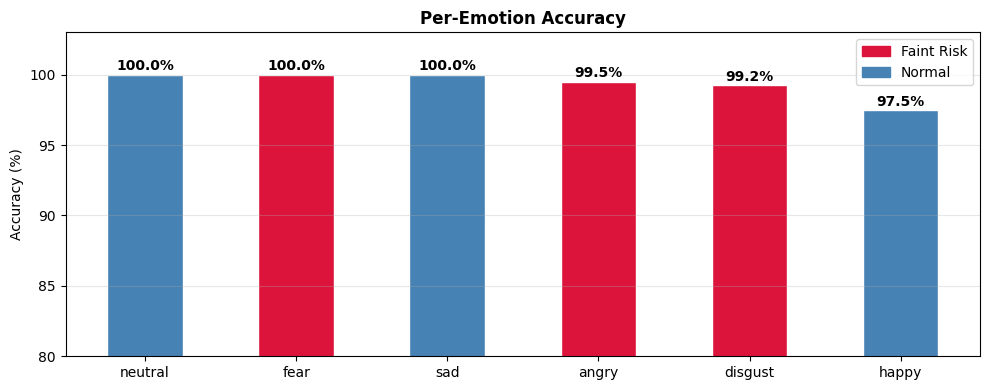

In [47]:
# Rebuild test indices to map back to emotions
# We re-extract embeddings for the original (non-augmented) files and evaluate per emotion

emotion_results = []
for emotion in sorted(df['emotion'].unique()):
    sub = df[df['emotion'] == emotion]
    embs, true_labels = [], []
    for _, row in sub.iterrows():
        embs.append(extract_embedding(row['path'], do_augment=False))
        true_labels.append(row['label'])
    embs = scaler.transform(np.array(embs, dtype=np.float32))
    p = (model.predict(embs, verbose=0).flatten() >= 0.5).astype(int)
    emotion_results.append({
        'Emotion': emotion,
        'Class': 'Faint Risk' if emotion in FAINT_EMOTIONS else 'Normal',
        'N': len(true_labels),
        'Accuracy': accuracy_score(true_labels, p),
        'F1': f1_score(true_labels, p)
    })

df_emo = pd.DataFrame(emotion_results).sort_values('Accuracy', ascending=False)
print('Per-Emotion Performance:')
print(df_emo.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
c = ['crimson' if r=='Faint Risk' else 'steelblue' for r in df_emo['Class']]
bars = ax.bar(df_emo['Emotion'], df_emo['Accuracy']*100, color=c, edgecolor='white', width=0.5)
for bar, val in zip(bars, df_emo['Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(80, 103); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Emotion Accuracy', fontsize=12, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='crimson',label='Faint Risk'), Patch(color='steelblue',label='Normal')])
plt.tight_layout()
plt.savefig('per_emotion_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 19 — Save All Artifacts

In [48]:
model.save('faint_detection_tess.h5')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

pd.DataFrame([{
    'accuracy': acc, 'precision': prec, 'recall': rec,
    'f1': f1, 'auc': auc, 'optimal_threshold': opt_thr
}]).to_csv('metrics_summary.csv', index=False)

print('✅ All artifacts saved:')
for f in ['faint_detection_tess.h5','scaler.pkl','metrics_summary.csv',
          'training_curves.png','confusion_matrix.png','roc_curve.png',
          'metrics_dashboard.png','prob_distribution.png','per_emotion_accuracy.png']:
    print(f'   - {f}')

✅ All artifacts saved:
   - faint_detection_tess.h5
   - scaler.pkl
   - metrics_summary.csv
   - training_curves.png
   - confusion_matrix.png
   - roc_curve.png
   - metrics_dashboard.png
   - prob_distribution.png
   - per_emotion_accuracy.png


---
## STEP 20 — Real-Time Prediction Function

In [49]:
def predict_file(path, threshold=0.5):
    emb = extract_embedding(path, do_augment=False)
    emb_scaled = scaler.transform([emb])
    prob = model.predict(emb_scaled, verbose=0)[0][0]
    label = 'FAINT RISK ⚠️' if prob >= threshold else 'Normal ✅'
    print(f'File        : {Path(path).name}')
    print(f'Probability : {prob:.4f}  ({prob*100:.1f}%)')
    print(f'Decision    : {label}')
    if prob >= threshold:
        print('🚨 EMERGENCY ALERT TRIGGERED')
    print()
    return prob, label

# Demo on a few files
print('=== Inference Demo ===')
for path in list((DATASET_ROOT / df[df.emotion=='neutral'].iloc[0]['path']).parent.glob('*.wav'))[:2]:
    predict_file(path)
for path in list((DATASET_ROOT / df[df.emotion=='fear'].iloc[0]['path']).parent.glob('*.wav'))[:2]:
    predict_file(path)

=== Inference Demo ===
File        : OAF_soup_neutral.wav
Probability : 0.0003  (0.0%)
Decision    : Normal ✅

File        : OAF_dime_neutral.wav
Probability : 0.0000  (0.0%)
Decision    : Normal ✅

File        : OAF_gap_fear.wav
Probability : 1.0000  (100.0%)
Decision    : FAINT RISK ⚠️
🚨 EMERGENCY ALERT TRIGGERED

File        : OAF_choice_fear.wav
Probability : 0.9847  (98.5%)
Decision    : FAINT RISK ⚠️
🚨 EMERGENCY ALERT TRIGGERED



---
## STEP 21 — Final Summary

In [50]:
print('\n' + '═'*60)
print('   🎙️  VOICE FAINT DETECTION — TESS — FINAL REPORT')
print('═'*60)
print()
print('  DATASET')
print('  ├─ Toronto Emotional Speech Set (TESS)')
print('  ├─ kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess')
print(f'  ├─ Raw files       : {len(df)}')
print(f'  ├─ After aug (×3)  : {len(X)}')
print(f'  ├─ Normal emotions : neutral, happy, sad')
print(f'  └─ Faint emotions  : fear, angry, disgust, ps')
print()
print('  ARCHITECTURE')
print('  ├─ YAMNet (Google) → 1024-dim embeddings')
print('  ├─ MLP: 512→256→128→64→1')
print('  ├─ BatchNorm + LeakyReLU + Dropout + L2')
print('  └─ EarlyStopping on val_AUC')
print()
print('  RESULTS')
print(f'  ├─ Accuracy  : {acc *100:.2f}%')
print(f'  ├─ Precision : {prec*100:.2f}%')
print(f'  ├─ Recall    : {rec *100:.2f}%')
print(f'  ├─ F1 Score  : {f1  *100:.2f}%')
print(f'  └─ ROC-AUC   : {auc *100:.2f}%')
print()
print('  PIPELINE')
print('  WAV → YAMNet → StandardScaler → MLP → Sigmoid → Alert')
print('═'*60)


════════════════════════════════════════════════════════════
   🎙️  VOICE FAINT DETECTION — TESS — FINAL REPORT
════════════════════════════════════════════════════════════

  DATASET
  ├─ Toronto Emotional Speech Set (TESS)
  ├─ kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
  ├─ Raw files       : 2400
  ├─ After aug (×3)  : 7200
  ├─ Normal emotions : neutral, happy, sad
  └─ Faint emotions  : fear, angry, disgust, ps

  ARCHITECTURE
  ├─ YAMNet (Google) → 1024-dim embeddings
  ├─ MLP: 512→256→128→64→1
  ├─ BatchNorm + LeakyReLU + Dropout + L2
  └─ EarlyStopping on val_AUC

  RESULTS
  ├─ Accuracy  : 97.87%
  ├─ Precision : 97.43%
  ├─ Recall    : 98.33%
  ├─ F1 Score  : 97.88%
  └─ ROC-AUC   : 99.81%

  PIPELINE
  WAV → YAMNet → StandardScaler → MLP → Sigmoid → Alert
════════════════════════════════════════════════════════════
